# **Linear Regression and Multiple Linear Regression Assignment**

## **Importing Libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

#### **Questions**

##### **1. Why do we use pandas?**

- Store structured data  
- Clean and preprocess data  
- Analyze and manipulate datasets  
- Work with tables using **DataFrames**
  
It makes data handling **faster, easier, and more organized** for:

- Data Analysis  
- Machine Learning  
- Data Science Projects

---

##### **2. What is the purpose of matplotlib and seaborn?**

- **Matplotlib** is used to create basic plots and charts such as:
    - Line plots
    - Bar charts
    - Histograms
    - Pie charts

- **Seaborn** is built on top of Matplotlib and used to create:
    - More attractive and advanced statistical visualizations
    - Heatmaps
    - Pair plots
    - Distribution plots

They help in understanding patterns, trends and relationships in data visually.

---

##### **3. Why is scikit-learn used?**

It provides simple tools for:

- Data preprocessing
- Training machine learning models
- Model evaluation
- Prediction and classification
- Feature selection and scaling

It supports many machine learning algorithms such as:

- Linear Regression
- Decision Trees
- K-Nearest Neighbors (KNN)
- Support Vector Machine (SVM)
- Clustering Algorithms

Scikit-learn makes machine learning easier, faster and more efficient.

### **Load Dataset**

In [2]:
df = pd.read_csv(r'C:\Users\DELL\OneDrive\Desktop\DataSets\SalaryMulti.csv')
df.head()

,Total Experience,Team Lead Experience,Project Manager Experience,Certifications,Salary
0,7,2,4,1,77318.070547
1,4,0,2,3,64951.950980
2,13,4,8,3,106058.185204
3,11,3,2,1,89649.944851
4,8,1,6,3,82206.019687


In [3]:
df.shape

(1000, 5)

#### **Questions**
##### **1. What does head() do?**
The 'head()' function is used to display the **first n rows** of a dataset.
By default it displays 5 rows.

---

##### **2. How many rows and columns are present in the dataset?**
There are **1000 rows** and **5 columns** in the dataset.

---
##### **3. Which column is the target/dependent variable?**
**Salary** is the target/dependent variable.

#### **Understanding of the Dataset Structure**

The dataset appears to contain information related to employees' professional experience, leadership roles, certifications, and salary details.

#### Columns Description

| Column Name | Description |
|---|---|
| **Total Experience** | Represents the total number of years of professional work experience of an employee. |
| **Team Lead Experience** | Indicates the number of years the employee has worked in a Team Lead role. |
| **Project Manager Experience** | Shows the years of experience the employee has as a Project Manager. |
| **Certifications** | Contains information about professional certifications obtained by the employee. |
| **Salary** | Represents the salary or compensation of the employee. |

#### Overall Understanding

The dataset can be used to analyze how:
- Work experience impacts salary
- Leadership experience affects compensation
- Certifications contribute to career growth and salary increase

This dataset is useful for:
- Salary prediction
- Employee analysis
- HR analytics

## **Exploratory Data Analysis (EDA)**

### **Understand Dataset Information**

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Total Experience            1000 non-null   int64  
 1   Team Lead Experience        1000 non-null   int64  
 2   Project Manager Experience  1000 non-null   int64  
 3   Certifications              1000 non-null   int64  
 4   Salary                      1000 non-null   float64
dtypes: float64(1), int64(4)
memory usage: 39.2 KB


In [5]:
df.describe()

,Total Experience,Team Lead Experience,Project Manager Experience,Certifications,Salary
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,7.443000,3.197000,1.629000,2.049000,81405.671673
std,4.113596,3.119282,2.148482,1.423596,18256.125772
min,1.000000,0.000000,0.000000,0.000000,42298.056827
25%,4.000000,1.000000,0.000000,1.000000,66045.779366
50%,7.000000,2.000000,1.000000,2.000000,81241.246184
75%,11.000000,5.000000,3.000000,3.000000,95624.152980
max,14.000000,13.000000,13.000000,4.000000,126221.716735


#### **Questions**

##### **1. What is the difference between `info()` and `describe()`?**

| Function | Purpose |
|---|---|
| **`info()`** | Provides a summary of the dataset including column names, data types, non-null values, and memory usage. |
| **`describe()`** | Generates statistical summary of numerical columns such as count, mean, standard deviation, minimum, and maximum values. |

---

##### **2. What does mean represent?**

In statistics, the **mean** represents the **average value** of a dataset.

It is calculated by dividing the **sum of all values** by the **total number of values**.

---

##### **3. What does standard deviation represent?**

Standard deviation represents how much the data values are spread out from the mean (average).

- A **low standard deviation** means the values are close to the mean.
- A **high standard deviation** means the values are more spread out.

It helps measure the variability or dispersion in a dataset.


#### **Observations**

### 1. Total Experience Analysis
- 50% of employees have experience less than or equal to **7 years**.
- Most employees fall between **4 to 11 years** of experience.

---

### 2. Team Lead Experience Analysis
- Some employees have **0 years**, meaning not everyone has leadership experience.
- The maximum Team Lead experience is **13 years**, indicating some highly experienced leaders.
- The high standard deviation (**3.12**) shows noticeable variation in leadership experience among employees.
- 75% of employees have Team Lead experience less than or equal to **5 years**.
- Only a smaller portion of employees have very high leadership experience.
  
---

### 3. Project Manager Experience Analysis
- 25% of employees have **0 years** of Project Manager experience.
- The median value is **1 year**, suggesting many employees are either beginners or have limited management exposure.
- The maximum value of **13 years** indicates a few highly experienced project managers.

---

### 4. Certifications Analysis
- Employees hold an average of approximately **2 certifications**.
- Most employees have between **1 and 3 certifications**.
- The low standard deviation indicates certifications are fairly evenly distributed among employees.

---

### 5. Salary Analysis
- The average salary is approximately **81,406**.
- Salaries range from around **42,298** to **126,222**.
- The median salary (**81,241**) is very close to the mean, suggesting the salary distribution is fairly balanced.
- 50% of employees earn between approximately **66,046 and 95,624**.
- The salary standard deviation (**18,256**) indicates moderate variation in employee salaries.

---

### 6. Relationship-Based Insights
- Employees with higher leadership and project management experience are likely associated with higher salaries.
- Certifications may positively influence salary growth and career advancement.

---

### 7. Distribution and Data Quality Observations
- No missing values are visible because the count for all columns is **1000**.
- The mean and median values are close in most columns, indicating limited skewness.
- The dataset appears clean, balanced, and well-structured for analysis and machine learning.

### **Task 4: Check Missing Values**

In [6]:
df.isnull().sum()

Total Experience              0
Team Lead Experience          0
Project Manager Experience    0
Certifications                0
Salary                        0
dtype: int64

#### **Questions**

##### **1. What are missing/null values?**

Missing or null values are empty spaces in a dataset where no data is stored for a particular row or column.

Missing values are usually represented as:

- `NaN` (Not a Number)
- `None`

### Example

| Name | Age |
|---|---|
| Ali | 20 |
| Sara | NaN |
| John | 22 |

Here, Sara’s age is missing, so it is considered a null value.

---

##### **2. Why is handling missing values important?**

Handling missing values is important because missing data can negatively affect data analysis and machine learning models.

If missing values are not handled properly, they can:
- Cause errors during computation
- Reduce model accuracy
- Produce incorrect analysis results
- Affect data quality and reliability

Missing values are commonly handled by:
  
- Removing missing data
- Filling values using `mean`, `median`, or `mode`
- Replacing with suitable default values

Proper handling of missing values improves the accuracy and quality of analysis.


#### **Observation**
The dataset does **not contain any missing value.**

### **Correlation Analysis**

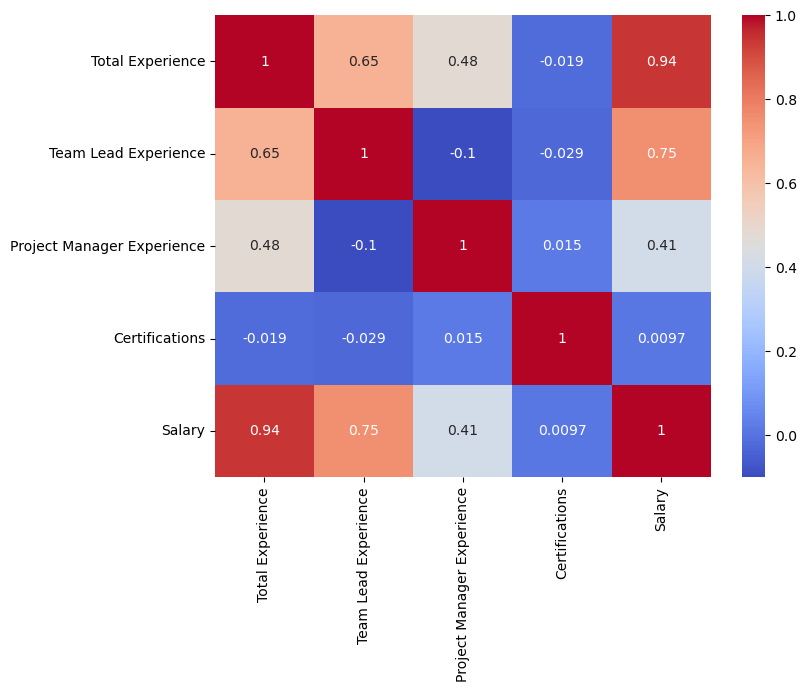

In [7]:
corr = df.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

#### **Questions**

##### **1. What is Correlation?**

Correlation is a statistical measure that shows the relationship between two variables.

It indicates:
- How strongly two variables are related
- Whether they move in the same or opposite direction

##### Types of Correlation

- **Positive Correlation** → When one variable increases, the other also increases.
- **Negative Correlation** → When one variable increases, the other decreases.
- **Zero Correlation** → No relationship between variables.

The correlation coefficient ranges from **-1 to 1**.

Where:
- `r = 1` → Perfect positive correlation
- `r = -1` → Perfect negative correlation
- `r = 0` → No correlation

**Example :** If experience increases and salary also increases, then they have a positive correlation.

---

##### **2. What does positive correlation mean?**

Positive correlation means that two variables move in the same direction.

- When one variable increases, the other also increases.
- When one variable decreases, the other also decreases.

**Example :** If employee experience increases and salary also increases, then experience and salary have a positive correlation.

----

##### **3. What does negative correlation mean?**

Negative correlation means that two variables move in opposite directions.

- When one variable increases, the other decreases.
- When one variable decreases, the other increases.

**Example :** If product price increases and customer demand decreases, then price and demand have a negative correlation.

 ---
 
##### **4. Which feature has the highest correlation with Salary?**

`Total Experience` has the highest correlation with `Salary`.

**Interpretation**
- This is a **very strong positive correlation**.
- It means that as total experience increases, salary also tends to increase significantly.

#### **Understanding of the Heatmap**

The heatmap represents the correlation between different features in the dataset. It helps identify how strongly variables are related to each other.

#### **Key Observations**

1. `Total Experience` has a very strong positive correlation with `Salary` (**0.94**), indicating that salary increases significantly with experience.

2. `Team Lead Experience` also shows a strong positive correlation with `Salary` (**0.75**), meaning leadership experience positively affects salary.

3. `Project Manager Experience` has a moderate positive correlation with `Salary` (**0.41**), suggesting it contributes to salary growth but less strongly.

4. `Certifications` have almost no correlation with `Salary` (**0.01**), indicating certifications alone may not significantly impact salary in this dataset.

5. `Total Experience` and `Team Lead Experience` are positively correlated (**0.65**), showing that employees with more overall experience often have leadership experience as well.

6. The negative correlation between `Team Lead Experience` and `Project Manager Experience` (**-0.10**) is very weak, meaning there is almost no inverse relationship between them.

##### **Overall Interpretation**

The heatmap shows that experience-related features are the most important factors influencing salary, while certifications have minimal impact on salary.

### **Task 6: Visualization**

#### **Histogram**

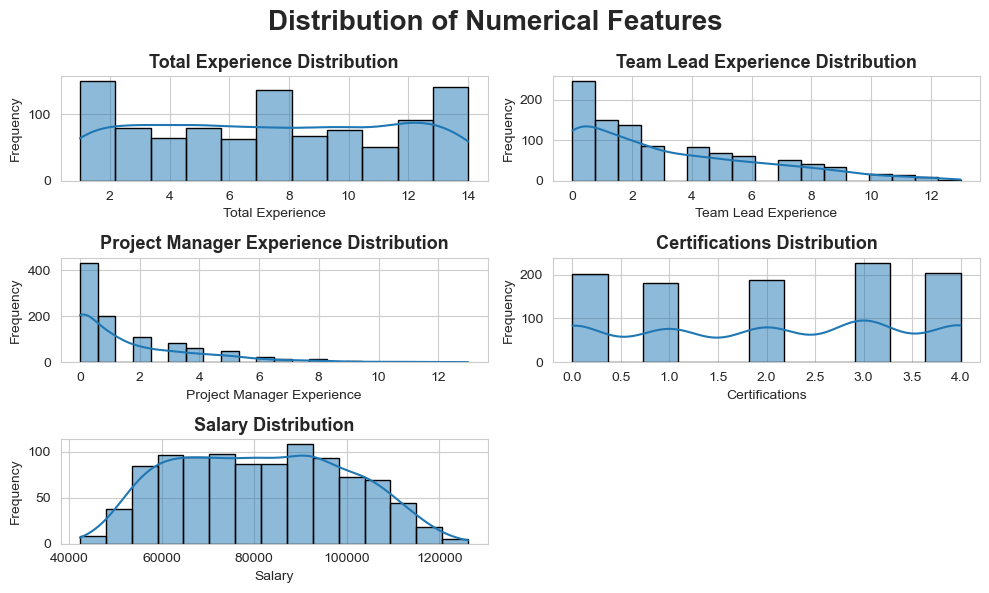

In [8]:
# Set better style
sns.set_style("whitegrid")

# Create subplots
fig, axes = plt.subplots(3, 2, figsize=(10, 6))
axes = axes.flatten()

# Plot each numerical column separately
for i, col in enumerate(df.select_dtypes(include='number').columns):

    sns.histplot(
        data=df,
        x=col,
        bins='auto',          # Automatically adjusts bins
        kde=True,             # Add smooth density curve
        ax=axes[i],
        edgecolor='black'
    )

    # Add title to each histogram
    axes[i].set_title(
        f"{col} Distribution",
        fontsize=13,
        fontweight='bold'
    )

    # set x and y label
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel("Frequency", fontsize=10)

# Remove empty subplot if present
if len(df.select_dtypes(include='number').columns) < len(axes):
    fig.delaxes(axes[-1])

# Main title
fig.suptitle(
    "Distribution of Numerical Features",
    fontsize=20,
    fontweight='bold'
)

# Better spacing
plt.tight_layout(rect=[0, 0, 1, 1])  # margins (left, bottom, right, top)

plt.show()

#### **Pair plot**

<Figure size 600x400 with 0 Axes>

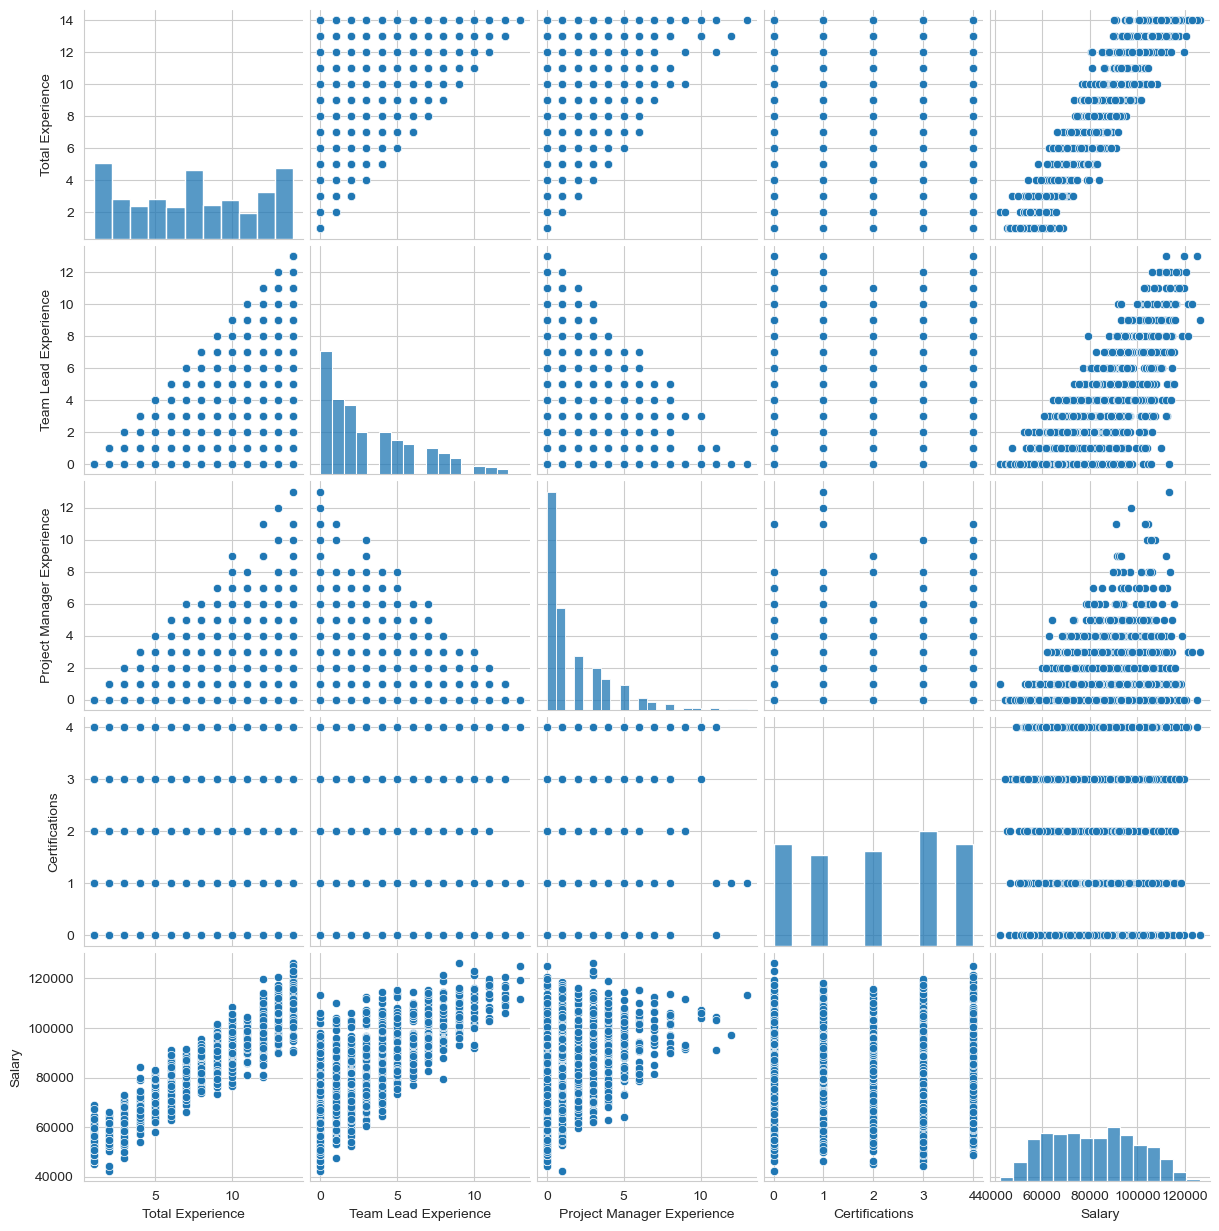

In [9]:
plt.figure(figsize=(6,4))
pair_plot = sns.pairplot(df)
pair_plot.savefig("pairplot.png")
# plt.show()

#### **Questions**

##### **1. What does a histogram show?**

A histogram shows the distribution of numerical data by displaying how frequently values occur within specific ranges (bins).

It helps in understanding:
- Data distribution
- Frequency of values
- Spread of data
- Skewness and patterns
- Presence of outliers

If a salary histogram has taller bars around a certain range, it means many employees have salaries within that range.

---

##### **2. What is distribution?**

Distribution refers to how data values are spread or arranged in a dataset.

It shows:
- Where most values are concentrated
- How values vary
- Whether the data is symmetric or skewed
- The spread and pattern of data

Distribution helps in understanding the overall behavior of data.

##### Example

In a salary dataset:
- If most salaries are around 80,000, the distribution is concentrated near that value.
- If some salaries are extremely high or low, the distribution becomes uneven or skewed.

Histograms are commonly used to visualize data distribution.

---

##### **3. What can you understand from a pairplot?**

A pairplot is used to visualize relationships between multiple numerical features in a dataset.

A pairplot helps understand:

- Correlation between variables
- Data distribution of each feature
- Trends and patterns
- Clusters in data
- Presence of outliers

##### What does it contain?

- **Scatter plots** between feature pairs
- **Histograms/KDE plots** on the diagonal

##### Example Understanding

From a pairplot, you can identify:
- Whether salary increases with experience
- Which features are positively or negatively correlated
- Whether data points are concentrated or scattered

# Detailed Analysis of Histogram and Pairplot

## 1. Total Experience Distribution

### Histogram Findings
- The `Total Experience` feature appears fairly evenly distributed between **1 and 14 years**.
- No extreme skewness is visible.
- Employees are spread across beginner, mid-level, and experienced categories.

### Pairplot Findings
- There is a **very strong positive relationship** between `Total Experience` and `Salary`.
- As total experience increases, salary consistently increases.
- The scatterplot forms an almost straight upward trend, indicating high correlation.

### Interpretation
`Total Experience` is the most influential feature affecting salary.

---

# 2. Team Lead Experience Distribution

### Histogram Findings
- Most employees have **low Team Lead experience** (0–5 years).
- Frequency decreases as experience increases.
- The distribution is **right-skewed**.

### Pairplot Findings
- `Team Lead Experience` has a strong positive relationship with `Salary`.
- Employees with more leadership experience generally receive higher salaries.
- A positive relationship is also visible with `Total Experience`.

### Interpretation
Leadership experience significantly contributes to salary growth.

---

# 3. Project Manager Experience Distribution

### Histogram Findings
- Most values are concentrated near **0–2 years**.
- Very few employees have high Project Manager experience.
- The distribution is highly **positively skewed**.

### Pairplot Findings
- Moderate positive relationship with salary.
- Employees with higher Project Manager experience tend to earn more, but the trend is weaker compared to Total Experience.

### Interpretation
Project management experience impacts salary, but not as strongly as overall or leadership experience.

---

# 4. Certifications Distribution

### Histogram Findings
- Certifications are discrete values ranging from **0 to 4**.
- Employees are relatively evenly distributed across certification counts.

### Pairplot Findings
- No clear relationship is visible between `Certifications` and `Salary`.
- Salary values are widely spread for every certification level.

### Interpretation
Certifications alone do not strongly influence salary in this dataset.

---

# 5. Salary Distribution

### Histogram Findings
- Salary distribution appears approximately **normal (bell-shaped)**.
- Most salaries lie between **60,000 and 100,000**.
- Very few employees have extremely low or extremely high salaries.

### Interpretation
The salary data is fairly balanced and does not contain severe skewness.

---


---

# 8. Overall Dataset Insights

### The visualizations indicate that:
- Experience-related features are the strongest drivers of salary.
- Leadership roles contribute significantly to higher compensation.
- Certifications have very little direct effect on salary.


#### **Summary of Visual Findings from Histogram and Pairplot**

1. The dataset appears clean and well-distributed, with no major missing patterns or extreme outliers visible in the visualizations.

2. No major extreme outliers are visible in salary. A few employees have very high Team Lead or Project Manager experience.

3. Salary shows a strong positive relationship with experience-related features, indicating that employees with higher experience generally earn higher salaries.

4. Leadership and management experience also contribute positively to salary growth, though their impact is weaker compared to total experience.

5. Certifications do not show a strong visible relationship with salary, suggesting they have limited direct influence on the salary.

6. Most numerical features are either normally distributed or slightly right-skewed, especially leadership and project management experience.

7. The pairplot clearly shows positive linear trends among experience-related variables.

8. Overall, experience is the strongest factor affecting salary.
#### **Relationship Analysis from Pairplot**

##### **Strong Positive Correlations**

| Features | Observation |
|---|---|
| Total Experience vs Salary | Very strong positive trend |
| Team Lead Experience vs Salary | Strong positive trend |
| Total Experience vs Team Lead Experience | Strong positive relationship |

---

##### **Moderate Correlations**

| Features | Observation |
|---|---|
| Project Manager Experience vs Salary | Moderate positive trend |
| Total Experience vs Project Manager Experience | Moderate positive relationship |

---

##### **Weak/No Correlations**

| Features | Observation |
|---|---|
| Certifications vs Salary | Almost no visible correlation |
| Certifications vs Experience Features | Weak relationship |



### **Simple Linear Regression**

#### **Select One Independent Variable**

In [10]:
x_simple = df[['Total Experience']]
y_simple = df['Salary']

#### **Question**

##### **1. What is an independent variable?**

An independent variable is the input feature or predictor variable that is used to influence or predict another variable.

It is the variable whose value is changed or used to analyze its effect on the dependent variable.

##### Example

In a salary prediction dataset:
- `Total Experience`
- `Team Lead Experience`
- `Project Manager Experience`
- `Certifications`

are independent variables because they are used to predict `Salary`.

##### Key Point

Independent variables are also called:
- Features
- Input variables
- Predictor variables

---

##### **2. What is a dependent variable?**

A dependent variable is the output or target variable whose value depends on the independent variables.

It is the variable that we want to predict or analyze.

##### Example

In a salary prediction dataset:

- `Salary` is the dependent variable because it depends on:
  - Total Experience
  - Team Lead Experience
  - Project Manager Experience
  - Certifications

##### Key Point

Dependent variables are also called:
- Target variables
- Output variables
- Response variables

---

##### **3. Why are double brackets used for `X`?**

Double brackets are used to select columns as a **DataFrame** (2-dimensional structure), while single brackets return a **Series** (1-dimensional structure).

Most machine learning models in scikit-learn require input features (X) in a 2D format because models expect:

- Rows → observations
- Columns → features

Even if there is only one feature, it should still be provided as a DataFrame.

Therefore, double brackets are used to maintain the correct structure for machine learning.

### **Split Dataset**

In [11]:
x_train_simple, x_test_simple, y_train_simple, y_test_simple = train_test_split(
    x_simple, y_simple, test_size=0.2, random_state=42
)

In [12]:
print('Shape of Training Dataset : ', x_train_simple.shape, y_train_simple.shape) 
print('Shape of Testing Dataset : ', x_test_simple.shape, y_test_simple.shape) 

Shape of Training Dataset :  (800, 1) (800,)
Shape of Testing Dataset :  (200, 1) (200,)


#### **Questions**

##### **1. Why do we split the dataset?**

The dataset is split to evaluate how well a machine learning model performs on unseen data.

Usually, the dataset is divided into:
- `Training data` → Used to train the model
- `Testing data` → Used to test the model

This helps to:
- Measure model accuracy
- Check model performance
- Prevent overfitting
- Ensure the model generalizes well to new data

---

##### **2. What is the purpose of training data?**

Training data is used to teach a machine learning model how to identify patterns and relationships in the dataset.

The model learns from the training data by:
- Analyzing input features (`X_train`)
- Comparing them with target values (`y_train`)
- Adjusting itself to make accurate predictions

##### Purpose of Training Data

- Train the model
- Learn patterns from data
- Build relationships between variables
- Improve prediction capability

The trained model can then predict salaries for new unseen data.

---

##### **3. What is the purpose of testing data?**

Testing data is used to evaluate how well a trained machine learning model performs on unseen data.

After the model learns from the training data, the testing data checks:
- Model accuracy
- Prediction performance
- Generalization ability
- Whether the model is overfitting or not

##### Purpose of Testing Data

- Test the trained model
- Measure prediction accuracy
- Evaluate model performance
- Validate how well the model works on new data

##### Example

In salary prediction:
- The model predicts salaries using `X_test`
- Predicted values are compared with actual salaries (`y_test`)
- This helps determine how accurate the model is

Testing data ensures the model performs well on real-world unseen data.

---

##### **4. What does `random_state` do?**

`random_state` is used to ensure reproducibility of random operations such as splitting datasets.

It controls the randomness so that the same output is generated every time the code runs.

##### Why is it important?

Without random_state:
- The train-test split changes every time the code runs.

With random_state=42:
- The same rows are selected for training and testing every time.

##### Benefits
- Reproducible results
- Consistent model evaluation
- Easier debugging and comparison

42 is commonly used as a standard random seed value, but any integer can be used.

### **Train Linear Regression Model**

In [13]:
model_simple = LinearRegression()
model_simple.fit(x_train_simple, y_train_simple)

LinearRegression()

#### **Questions**

##### **1. What does `fit()` do?**

The `fit()` method is used to train a machine learning model using the training data.

It helps the model learn patterns and relationships between:
- Input features (`X_train`)
- Target values (`y_train`)

##### What happens during fit()?

The model:

- Analyzes the training data
- Learns relationships between variables
- Adjusts internal parameters
- Builds a prediction model

##### Example Understanding

In salary prediction:

- The model learns how salary changes with experience.
- After training, it can predict salaries for new employees.

---

##### **2. What is model training?**

Model training is the process of teaching a machine learning model to learn patterns and relationships from data.

During training, the model:
- Takes input features (`X_train`)
- Compares predictions with actual outputs (`y_train`)
- Adjusts its parameters to improve accuracy

##### Purpose of Model Training

- Learn from data
- Identify relationships between variables
- Build a predictive model
- Improve prediction accuracy

##### Example

In salary prediction:
- The model learns how features like experience and certifications affect salary.
- After training, the model can predict salaries for new employees.

---

##### **3. What is the equation of Linear Regression?**

`y = mx + b`
##### Where:

| Symbol | Meaning |
|---|---|
| `y` | Predicted output (dependent variable) |
| `x` | Input feature (independent variable) |
| `m` | Slope or coefficient |
| `b` | Intercept |

##### Explanation

- `m` shows how much `y` changes when `x` increases by 1 unit.
- `b` is the value of `y` when `x = 0`.

##### Example

In salary prediction:
- `x` → Total Experience
- `y` → Salary

The model learns a line that best fits the data points to predict salary based on experience.

---

#### **What the Model is Learning?**

The model is learning the relationship between `Total Experience` and `Salary`.

It learns how salary changes as employee experience increases.

Using the training data, the model identifies a pattern between experience and salary and uses this relationship to predict salary for new employees based on their total experience.

### **Model Coefficients**

In [14]:
print(model_simple.coef_)
print(model_simple.intercept_)

[4174.30797292]
50305.47797178812


#### **Questions**

##### **1. What is slope/coefficient?**

In linear regression, the slope or coefficient represents the amount by which the dependent variable changes when the independent variable increases by one unit.

In the equation:

- `m` represents the slope/coefficient.

##### Interpretation

- A positive slope means `y` increases as `x` increases.
- A negative slope means `y` decreases as `x` increases.

##### Example

In salary prediction:
- If the slope is `5000`,
- It means salary increases by approximately **5000 units** for every additional year of experience.

---

##### **2. What is intercept?**

In linear regression, the intercept is the value of the dependent variable when the independent variable is zero.

In the equation:

- `b` represents the intercept.

##### Interpretation

The intercept shows the starting value of `y` before any effect of `x`.

##### Example

In salary prediction:
- If the intercept is `30000`,
- It means the predicted salary is 30,000 when experience is 0 years (for freshers).

---

##### **3. What does the coefficient tell us in this problem?**

In this salary prediction problem, the coefficient tells us the salary increases by `4174.30797292` for every one-unit increase in `Total Experience`.


### **Predictions**

In [15]:
y_pred_simple = model_simple.predict(x_test_simple)

#### **Questions**

##### **1. What are predictions?**

Predictions are the output values generated by a machine learning model based on input data.

After training, the model uses learned patterns to estimate or predict unknown values.

##### Example

In salary prediction:
- The model takes employee experience as input
- It predicts the expected salary as output

Here:

- `X_test` → Input data
- `y_pred` → Predicted salaries

Predictions help evaluate how well the model performs on unseen data.

---

##### **2. How does the model generate predictions?**

The model generates predictions by using the patterns and relationships learned during training.

In linear regression, the model uses the equation `y = mx + b`


Where:
- `x` → Input feature (e.g., Total Experience)
- `m` → Coefficient/slope
- `b` → Intercept
- `y` → Predicted output (Salary)

The model substitutes the input value into the equation and calculates the predicted salary.

##### Example

If:
- `m = 5000`
- `b = 30000`
- `x = 5`

Then: `y = 5000 * 5 + 30000`

So, the predicted salary is **55,000**.

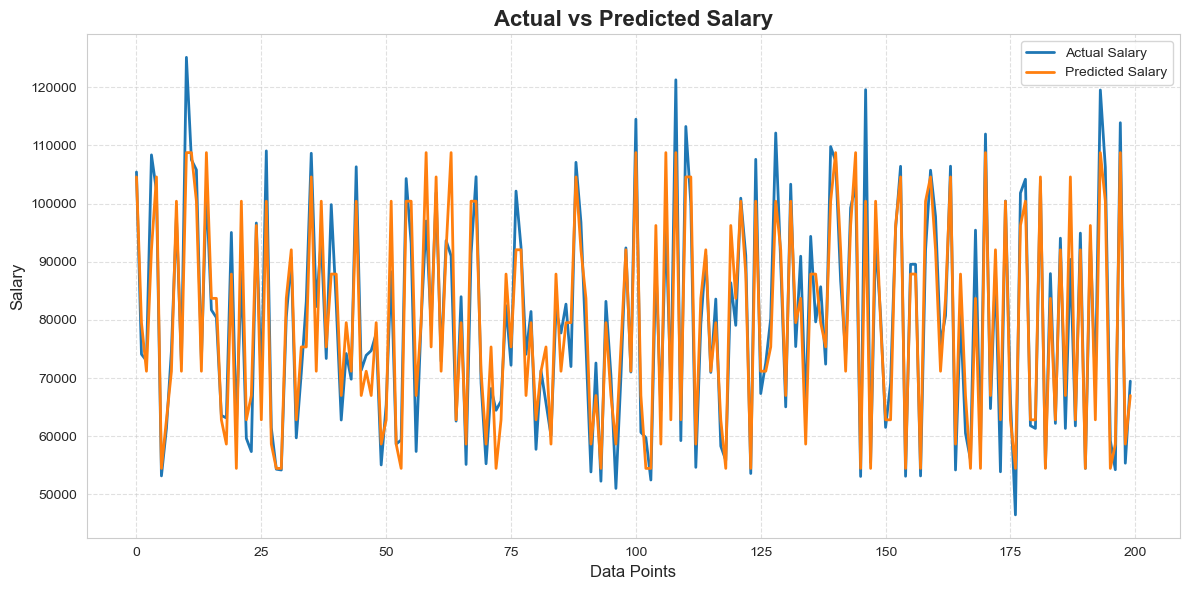

In [16]:
# Create comparison DataFrame
d = {
    'Actual_Value': y_test_simple,
    'Predicted_Value': y_pred_simple
}

comp_simple_df = pd.DataFrame(d).reset_index(drop=True)

# Plot
plt.figure(figsize=(12, 6))

# Actual Value
plt.plot(
    comp_simple_df['Actual_Value'],
    label='Actual Salary',
    linewidth=2
)

# Predicted Value
plt.plot(
    comp_simple_df['Predicted_Value'],
    label='Predicted Salary',
    linewidth=2
)

# Title and labels
plt.title("Actual vs Predicted Salary", fontsize=16, fontweight='bold')
plt.xlabel("Data Points", fontsize=12)
plt.ylabel("Salary", fontsize=12)

# Grid and legend
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

### **Evaluation Metrics**

In [17]:
mse_simple = mean_squared_error(y_test_simple, y_pred_simple)
mae_simple = mean_absolute_error(y_test_simple, y_pred_simple)
r2_simple = r2_score(y_test_simple, y_pred_simple)

print(f"{'Metric':<15} {'Value'}")
print("-"*30)
print(f"{'MSE':<15} {mse_simple:.2f}")
print(f"{'MAE':<15} {mae_simple:.2f}")
print(f"{'R2 Score':<15} {r2_simple:.2f}")

Metric          Value
------------------------------
MSE             34027746.96
MAE             4600.56
R2 Score        0.90


#### **Questions**

##### **1. What is Mean Squared Error (MSE)?**

Mean Squared Error (MSE) is a metric used to measure the average squared difference between actual values and predicted values.

It helps evaluate how well a machine learning model is performing.

The formula for MSE : $$MSE = \frac{1}{n} \sum (y_i - p_i)^2$$
- where:
    - `yi` → observed value,
    - `pi` → predicted value,
    - `n` → number of observations. 


##### Interpretation

- Lower MSE → Better model performance
- Higher MSE → Larger prediction errors

---

##### **2. Why are errors squared?**

Errors are squared in Mean Squared Error (MSE) to:

- Remove negative values so positive and negative errors do not cancel each other
- Penalize large errors(outliers) more heavily
- Make the metric more sensitive to bigger prediction mistakes

---

##### **3. What is Mean Absolute Error (MAE)?**

Mean Absolute Error (MAE) is a metric used to measure the average absolute difference between actual values and predicted values.

It shows how far the predictions are from the actual values on average.

The formula for MAE :
$$
MAE = \frac{1}{n} \sum |yi - pi|
$$
- where:
    - `yi` → observed value,
    - `pi` → predicted value,
    - `n` → number of observations. 

##### Interpretation

- Lower MAE → Better model performance
- Higher MAE → Larger prediction errors

MAE is easy to understand because it measures the average prediction error directly in the original units.

---

##### **4. What is R² Score?**

R² Score (Coefficient of Determination) is a metric used to measure how well a regression model explains the variation in the target variable.

It indicates how accurately the model fits the data.

The formula for R² Score is: $$R^2 = 1 - \frac{SS_{res}}{SS_{tot}}$$
- Where, 
    - R2 → required R Squared value,
    - $SS_{res}$ → Residual Sum of Squares, 
    - $TSS_{tot}$ → Total Sum of Squares.

$SS_{res} = \sum (yi − pi)²$
- where:
    - `yi` → observed value,
    - `pi` → predicted value.

$SS_{tot} = \sum (yi − \bar{y})²$

- where:
    - `yi` → observed value,
    - `ymean` → mean value
##### Interpretation

- `R² = 1` → Perfect prediction
- `R² = 0` → Model performs no better than predicting the mean
- Higher R² Score → Better model performance

##### Example

If the R² score is **0.94**, it means the model explains **94% of the variance** in the target variable.

---

##### **5. Why is R² Score important?**

R² Score is important because it measures how well a regression model explains the variation in the target variable.

It helps determine:
- Model accuracy
- Goodness of fit
- Prediction performance

R² Score helps compare regression models and evaluate how effectively the model fits the data.

---

##### **6. Which metric is better: lower MSE or higher MSE?**

A lower Mean Squared Error (MSE) is better.

- Lower MSE indicates that the predicted values are closer to the actual values.
- Higher MSE indicates larger prediction errors and poorer model performance.

Therefore:
- Lower MSE → Better model accuracy
- Higher MSE → Worse model accuracy

#### Interpretation of Evaluation Metrics

##### **1. Mean Squared Error (MSE)**
- MSE measures the average squared difference between actual and predicted values.
- A lower MSE indicates better model performance.
- Higher MSE means the model predictions contain larger errors.
- It is sensitive to outliers and penalizes it.

---

##### **2. Mean Absolute Error (MAE)**
- MAE measures the average absolute difference between actual and predicted values.
- It shows how far predictions are from actual values on average.
- Lower MAE indicates more accurate predictions.
- It gives the value in same unit so easier to evaluate.

---

##### **3. R² Score**
- R² Score measures how well the model explains the variation in the target variable.
- Values closer to `1` indicate better model performance.
- A high R² Score means the model fits the data well and makes accurate predictions.

---

##### **Overall Interpretation**

- Lower MSE and MAE indicate smaller prediction errors.
- Higher R² Score indicates better prediction capability and model accuracy.
- Together, these metrics help evaluate the effectiveness of the regression model.

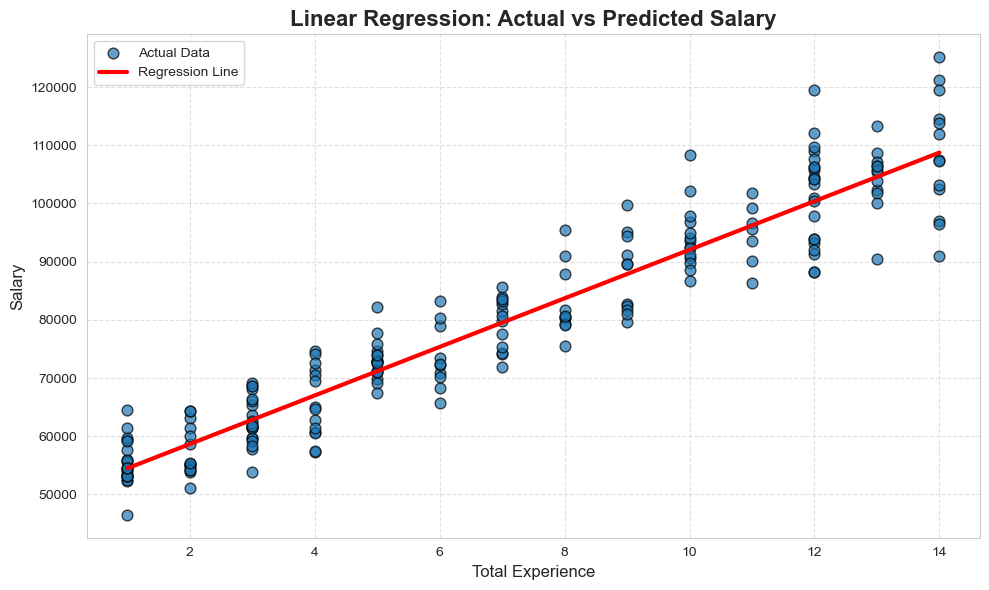

In [18]:
# Create figure
plt.figure(figsize=(10, 6))

# Scatter plot for actual data
plt.scatter(
    x_test_simple,
    y_test_simple,
    s=60,
    alpha=0.7,
    edgecolor='black',
    label='Actual Data'
)

# Sort values for smooth regression line
sorted_indices = x_test_simple.squeeze().argsort()

plt.plot(
    x_test_simple.squeeze().iloc[sorted_indices],
    # x_test,y_pred,
    y_pred_simple[sorted_indices],
    color='red',
    linewidth=3,
    label='Regression Line'
)

# Labels and title
plt.xlabel('Total Experience', fontsize=12)
plt.ylabel('Salary', fontsize=12)

plt.title(
    'Linear Regression: Actual vs Predicted Salary',
    fontsize=16,
    fontweight='bold'
)

# Grid and legend
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Better spacing
plt.tight_layout()

plt.show()

#### **Questions**

##### **1. What does the regression line represent?**

The **regression line** represents the **best-fit relationship** between the input variable(s) and the output variable in a dataset.

- It shows the **overall trend** of the data  
- It predicts the **average expected value** of the output for a given input  
- It is the line that **minimizes the total error (residuals)** between actual data points and predicted values  

##### Example:
- X = study hours  
- Y = marks  

Then the regression line shows how **marks generally change as study hours increase**.

##### Key idea:
Even though all points do not lie on the line, the regression line gives the **best straight-line approximation** of the relationship between variables.

---

##### **2. Why are some points away from the line?**

Some points are away from the regression line because the line is a **best-fit approximation**, not a perfect representation of all data points.

##### Main reasons:

- **Real-world noise** : Data often contains randomness, measurement errors, or fluctuations.  
- **Missing factors** : The model may not include all variables that affect the output.  
- **Natural variation** : Even with the same input, outputs can differ in real life.  
- **Model simplification** : A linear regression assumes a straight-line relationship, while the real relationship may be more complex.  

##### Key term:
The distance between a point and the regression line is called a **residual (error)**.

- Small residual → good prediction  
- Large residual → poor prediction for that point  

##### Key idea:
The regression line captures the overall trend, but individual points can still deviate due to real-world unpredictability.

---

#### **Fit of the Regression Line**

The **fit of a regression line** describes how well the line represents the actual data points in a dataset.

##### Good Fit:
A regression line is said to have a **good fit** when:
- Most data points are **close to the line**
- Residuals (errors) are **small**
- The line accurately captures the **trend in the data**

##### Poor Fit:
A regression line has a **poor fit** when:
- Data points are **widely scattered away from the line**
- Residuals are **large**
- The line does not represent the true pattern well

##### How we measure fit:
The goodness of fit is commonly measured using:
- **R² (R-squared)**: shows how much variation in the output is explained by the model  
- **Mean Squared Error (MSE)**: average squared difference between actual and predicted values  

##### Key idea:
A perfect fit means all points lie exactly on the line (rare in real life). In practice, we aim for a line that minimizes error and best captures the overall pattern in the data.

## **Multiple Linear Regression**

#### **Select Multiple Features**

In [19]:
x_multi = df.drop(columns=['Salary'], axis=1)
y_multi = df['Salary']

#### **Questions**

##### **1. What is Multiple Linear Regression?**

**Multiple Linear Regression (MLR)** is a statistical method used to model the relationship between **one dependent variable** and **two or more independent variables** using a linear equation.

##### General Form
$$
Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \beta_3 X_3 + \cdots + \beta_n X_n
$$
- Where:
    - $Y$ → Dependent variable (target/output)
    - $X_1, X_2, X_3, ...$ → Independent variables (features/input)
    - $ \beta_0 $ → Intercept (value of Y when all X = 0)
    - $ \beta_1, \beta_2, \beta_3, ... $ → Coefficients (impact of each feature on Y)

**Key idea:** Each independent variable contributes to predicting the output, and the model finds the **best-fitting linear relationship** that minimizes prediction error.

##### Example:
We want to predict **Salary** using multiple features:

- Total Experience  
- Team Lead Experience  
- Project Manager Experience  
- Certifications  
Then MLR finds how each factor influences the Salary.

##### Summary:
Multiple Linear Regression extends simple linear regression by using **multiple inputs to improve prediction accuracy**.

---

##### **2. Why do we use multiple features?**

We use multiple features in **Multiple Linear Regression** because real-world outcomes usually depend on **more than one factor**.

##### **Main reasons:**

##### 1. Better accuracy
Using only one feature (like total experience) may not fully explain salary.  
Adding more features improves prediction accuracy.

##### 2. Real-world complexity
Salary depends on many factors, such as:
- Total experience  
- Team lead experience  
- Project manager experience  
- Certifications  

Each factor contributes differently.

##### 3. Capture hidden relationships
Some features may influence salary in different ways:
- Certifications may increase salary even with low experience  
- Leadership experience may have higher impact than general experience  

##### 4. Reduce prediction error
More relevant features help reduce **residual errors**, making the model more reliable.

##### Key idea:
Multiple features help the model understand the problem more completely, leading to **better and more realistic predictions**.

---

##### **3. What are the advantages over simple linear regression?**

| Advantage | Explanation |
|----------|-------------|
| Uses multiple factors | MLR uses more than one independent variable, making it more realistic than SLR which uses only one. |
| Better prediction accuracy | By considering more features, MLR generally produces more accurate predictions. |
| Captures complex relationships | It can model the combined effect of multiple variables on the target. |
| Reduces bias | Including important variables reduces the risk of missing key influences. |
| More practical | Suitable for real-world problems like salary, house price, and demand prediction. |

##### Key Idea:
MLR improves upon Simple Linear Regression by using multiple inputs to better understand and predict outcomes.

### **Split Dataset**

In [20]:
x_train_multi, x_test_multi, y_train_multi, y_test_multi = train_test_split(
    x_multi, y_multi, test_size=0.2, random_state=42
)

In [21]:
print('Shape of Training Data: ', x_train_multi.shape, y_train_multi.shape)
print('Shape of Testing Data: ', x_test_multi.shape, y_test_multi.shape)

Shape of Training Data:  (800, 4) (800,)
Shape of Testing Data:  (200, 4) (200,)


### **Train Multiple Linear Regression Model**

In [22]:
multi_model = LinearRegression()
multi_model.fit(x_train_multi, y_train_multi)

LinearRegression()

#### **Questions**

##### **1. What changes compared to Simple Linear Regression?**

When we move from **Simple Linear Regression (SLR)** to **Multiple Linear Regression (MLR)**, several important changes happen:

##### 1. Number of input variables
| Simple Linear Regression | Multiple Linear Regression |
|--------------------------|----------------------------|
| Uses **one independent variable (X)** | Uses **two or more independent variables (X₁, X₂, X₃...)** |

##### 2. Model equation
- SLR:
$
Y = \beta_0 + \beta_1 X
$

- MLR:
$
Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \cdots + \beta_n X_n
$

##### 3. Complexity
| SLR | MLR |
|-----|-----|
| Simple relationship | More complex relationship |
| Easy to visualize (2D line) | Harder to visualize (multi-dimensional plane) |

##### 4. Information used
- SLR uses **limited information (one feature)**  
- MLR uses **multiple features**, capturing more real-world factors  

##### 5. Prediction quality
- SLR may miss important factors  
- MLR usually gives **better and more accurate predictions**

##### Key idea:
The main change is that **MLR extends SLR by adding multiple input variables**, making the model more realistic and powerful.

---

##### **2. How does the model handle multiple variables?**

In Multiple Linear Regression (MLR), the model handles multiple variables by **assigning a separate weight (coefficient) to each feature** and combining them linearly.

##### 1. Separate contribution of each feature
Each independent variable gets its own coefficient:
- Total Experience → β₁  
- Team Lead Experience → β₂  
- Project Manager Experience → β₃  
- Certifications → β₄  

Each coefficient shows how much that variable influences the output.

##### 2. Combined linear equation
All variables are combined into one equation:

$$
Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \beta_3 X_3 + \cdots + \beta_n X_n
$$

The model adds all contributions together to make the final prediction.

##### 3. Independent effect assumption
The model assumes:
- Each variable affects the output independently (while keeping others constant)

##### Key idea:
MLR handles multiple variables by giving each feature its own coefficient and combining them into a single predictive equation.

#### **Model Training Process (Multiple Linear Regression)**

The training process of Multiple Linear Regression is how the model learns the best relationship between input features and the output variable.

##### 1. Input data preparation
We start with a dataset containing:
- Independent variables (X):  
  Total Experience, Team Lead Experience, Project Manager Experience, Certifications  
- Dependent variable (Y):  
  Salary  

##### 2. Define the model equation
The model assumes a linear relationship:

$$
Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \beta_3 X_3 + \cdots + \beta_n X_n
$$

##### 3. Initialize parameters
- The model starts with initial values of coefficients (β₀, β₁, β₂, …), often random or zero.

##### 4. Make predictions
For each data point, the model:
- Substitutes input values into the equation  
- Generates predicted salary (Ŷ)

##### 5. Calculate error (loss)
The error is calculated using a loss function, usually:

- **Mean Squared Error (MSE)**: Measures the difference between actual and predicted values

##### 6. Optimize coefficients
The model adjusts coefficients (β values) to reduce error using:
- **Ordinary Least Squares (OLS)** or  
- **Gradient Descent**

##### 7. Repeat until best fit
Steps 4–6 are repeated until:
- Error becomes minimum  
- Coefficients converge to optimal values  

### Key idea:
Training in MLR means finding the best values of coefficients (β₀, β₁, β₂, …) so that the model predictions are as close as possible to actual values.

### **Coefficients Interpretation**

In [23]:
coef_multi_df = pd.DataFrame({
    'Feature': x_multi.columns,
    'Coefficient': multi_model.coef_
})
coef_multi_df

,Feature,Coefficient
0,Total Experience,2988.174865
1,Team Lead Experience,1898.171077
2,Project Manager Experience,974.703341
3,Certifications,371.321697


#### **Questions**

##### **1. Which feature has highest impact on salary?**

`Total Experience` has highest impact on salary.

---

##### **2. Which feature has lowest impact on salary?**

`Certifications` has lowest impact on salary.

---

##### **3. What does a negative coefficient mean?**

In Multiple Linear Regression, a **negative coefficient** means that the feature has an **inverse relationship** with the target variable.

If a coefficient (β) is negative, then:
- When that feature increases, the predicted value (Salary) **decreases**
- When that feature decreases, the predicted value (Salary) **increases**

##### Example:

Suppose:
- β₂ (Team Lead Experience) = -2000  

Then:
- Each additional unit of **Team Lead Experience** reduces the predicted salary by ₹2000  
- Keeping all other features constant


##### Important concept:
This interpretation is always done **“keeping other variables constant”** (ceteris paribus).

##### Why can coefficients be negative?

- The feature may have a **true negative impact** on the target  
- **Multicollinearity** (features correlated with each other)  
- Data patterns in training dataset  

##### Key idea:
A negative coefficient shows an **inverse relationship** between a feature and the target variable in the regression model.

#### **Interpretation all coefficients**

Each coefficient means:

- **β₀ (Intercept)** → Base salary when all features are 0  
- **β₁, β₂, β₃, β₄** → Change in salary when that feature increases by 1 unit  

👉 Important rule:  
**All interpretations are done while keeping other variables constant.**


| Coefficient | Meaning |
|-------------|--------|
| β₀ (Intercept) | Expected salary when all experiences and certifications are 0 (50769.34540329706) |
| β₁ (Total Experience) | For 1 unit of change, salary changes by 2988.17486511 |
| β₂ (Team Lead Experience) | For 1 unit of change, salary changes by 1898.17107701 |
| β₃ (Project Manager Experience) | For 1 unit of change, salary changes by 974.70334101 |
| β₄ (Certifications) | For 1 unit of change, salary changes by 371.32169738 |

##### Example interpretation

If:
- β₁ = 3000  

Then:
- Every 1-year increase in **Total Experience** increases salary by **₹3000**, assuming other factors remain constant.
  

### **Predictions and Evaluations**

In [24]:
y_pred_multi = multi_model.predict(x_test_multi)

mse_multi = mean_squared_error(y_test_multi, y_pred_multi)
mae_multi = mean_absolute_error(y_test_multi, y_pred_multi)
r2_multi = r2_score(y_test_multi, y_pred_multi)

print(f"{'Metric':<15} {'Value'}")
print("-"*30)
print(f"{'MSE':<15} {mse_multi:.2f}")
print(f"{'MAE':<15} {mae_multi:.2f}")
print(f"{'R2 Score':<15} {r2_multi:.2f}")

Metric          Value
------------------------------
MSE             20819427.98
MAE             3733.83
R2 Score        0.94


### **Compare Performance of Simple and Multiple Linear Regression Models**

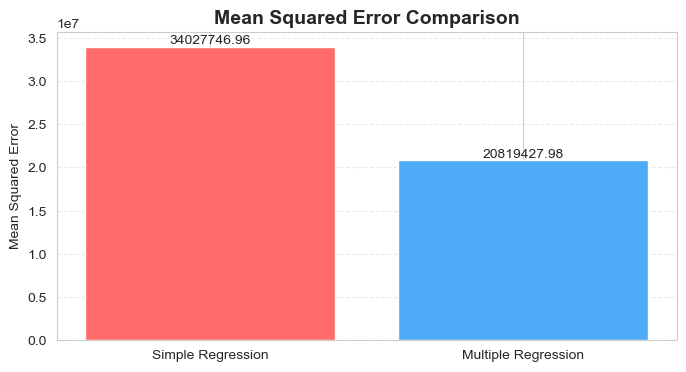

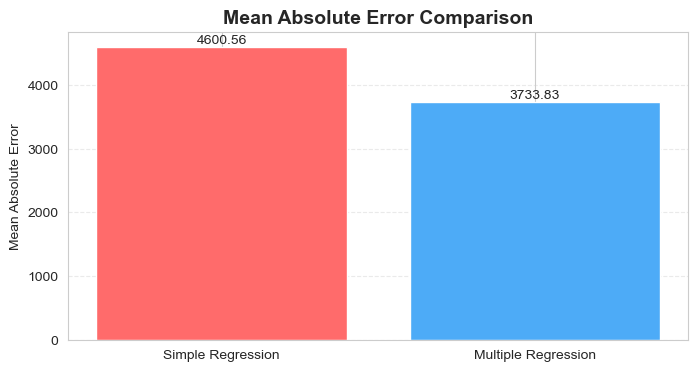

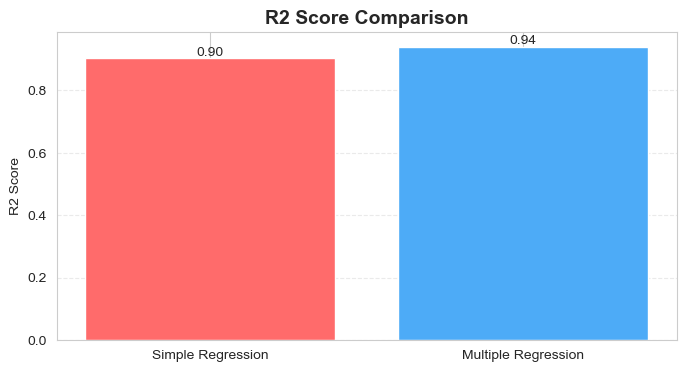

In [34]:
models = ["Simple Regression", "Multiple Regression"]
metric_values = [[mse_simple, mse_multi],[mae_simple, mae_multi],[r2_simple, r2_multi]]

index = ["Mean Squared Error", "Mean Absolute Error", "R2 Score"]
for ind, metric in zip(index,metric_values):
    plt.figure(figsize=(8,4))
    bars = plt.bar(models, metric, color=["#ff6b6b", "#4dabf7"])
    
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height,
             f"{height:.2f}",
             ha='center', va='bottom', fontsize=10)
        
    plt.title(f"{ind} Comparison", fontsize=14, fontweight='bold')
    plt.ylabel(ind)
    
    plt.grid(axis='y', linestyle='--', alpha=0.4)
    plt.show()


#### **Questions**

##### **Which model performed better?**

Multiple Linear Regression performed better than Simple Linear Regression.

---

##### **Why did performance improve?**
Multiple Linear Regression performed better as it uses multiple features to predict Salary of an employee rather than taking just 1 featrue Total Experience.

The influence of Total Experience on Salary is so high. But still it alone does not capture all the aspects to predict Salary.

## Detailed Comparison: Simple Linear Regression vs Multiple Linear Regression

The performance of the Multiple Linear Regression (MLR) model was compared with the Simple Linear Regression (SLR) model using three evaluation metrics:

- Mean Squared Error (MSE)
- Mean Absolute Error (MAE)
- R² Score

---

## 1. Mean Squared Error (MSE)

- MSE measures the average squared difference between actual and predicted values.
- Lower MSE indicates better prediction accuracy.

### Observation:
The Multiple Linear Regression model produced a lower MSE compared to the Simple Linear Regression model.

### Interpretation:
This means the predictions made by the MLR model were closer to the actual salary values, resulting in smaller prediction errors.

---

## 2. Mean Absolute Error (MAE)

- MAE measures the average absolute difference between actual and predicted values.
- Lower MAE indicates better model performance.

### Observation:
The MAE value of the Multiple Linear Regression model was lower than that of the Simple Linear Regression model.

### Interpretation:
This indicates that the MLR model made more accurate predictions on average compared to the SLR model.

---

## 3. R² Score

- R² Score measures how well the model explains the variance in the target variable.
- Higher R² indicates better explanatory power.

### Observation:
The Multiple Linear Regression model achieved a higher R² score than the Simple Linear Regression model.

### Interpretation:
This shows that the MLR model explained more variation in salary because it used multiple relevant features instead of only one.

---

## Overall Performance Comparison

| Metric | Simple Linear Regression |Multiple Linear Regression | Better Direction | Better Model |
|--------|--------------------------|---------------------------|------------------|--------------|
| MSE | 34027746.9581 | 20819427.9758 | Lower | Multiple Linear Regression |
| MAE | 4600.5623 | 3733.8308 | Lower | Multiple Linear Regression |
| R² Score |0.9029 | 0.9406 | Higher | Multiple Linear Regression |

---

## Final Conclusion

The performance of the model improved significantly when moving from Simple Linear Regression to Multiple Linear Regression.

The Multiple Linear Regression model performed better because:
- It used multiple input features
- It captured more information from the dataset
- It reduced prediction error
- It explained the target variable more effectively

Therefore, Multiple Linear Regression provided more accurate and reliable salary predictions compared to Simple Linear Regression.